# English–Amharic NMT Dataset Audit

This notebook performs an exploratory audit of the raw English–Amharic parallel corpus before cleaning and preprocessing.

The audit covers:

- Dataset structure and size
- Missing and empty values
- Duplicate sentence pairs
- Sentence-length statistics
- Length-ratio analysis
- URL and markup inspection
- Ethiopic-script validation
- Potentially problematic sentence pairs

**Important:** This notebook does not modify the raw dataset.

## Imports and project path

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Imports completed.")

Matplotlib is building the font cache; this may take a moment.


Imports completed.


## Locate project root

In [2]:
PROJECT_ROOT = Path.cwd()

# This supports running the notebook either from the project root
# or from inside the notebooks/ directory.
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_FILE = PROJECT_ROOT / "data" / "raw" / "mt560_amharic_english" / "train.parquet"

print("Project root:", PROJECT_ROOT)
print("Raw dataset :", RAW_FILE)
print("Exists      :", RAW_FILE.exists())

if not RAW_FILE.exists():
    raise FileNotFoundError(
        f"Raw dataset was not found at: {RAW_FILE}\n"
        "Please confirm that the dataset was downloaded correctly."
    )

Project root: c:\Users\olibe\Desktop\neural-machine-translation
Raw dataset : c:\Users\olibe\Desktop\neural-machine-translation\data\raw\mt560_amharic_english\train.parquet
Exists      : True


## 1. Load the Raw Dataset

In [3]:
df = pd.read_parquet(RAW_FILE)

print(f"Dataset loaded successfully.")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

display(df.head())

Dataset loaded successfully.
Rows    : 669,145
Columns : ['eng', 'amh']


,eng,amh
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?


### Dataset shape

In [4]:
print("Dataset shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset shape:
Rows    : 669,145
Columns : 2


### Column names and data types

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

Column names:
['eng', 'amh']

Data types:


,dtype
eng,str
amh,str


### Basic dataset information

In [6]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 669145 entries, 0 to 669144
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   eng     669145 non-null  str  
 1   amh     669145 non-null  str  
dtypes: str(2)
memory usage: 181.8 MB


## 2. Required Columns

The dataset is expected to contain:

- `eng`: English source sentence
- `amh`: Amharic target sentence

### Validate required columns

In [7]:
REQUIRED_COLUMNS = {"eng", "amh"}

missing_columns = REQUIRED_COLUMNS - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print("Required columns are present:", sorted(REQUIRED_COLUMNS))

Required columns are present: ['amh', 'eng']


## 3. Missing-Value Audit

In [8]:
missing_report = pd.DataFrame({
    "missing_count": df[["eng", "amh"]].isna().sum(),
    "missing_percentage": (
        df[["eng", "amh"]].isna().mean() * 100
    ).round(4),
})

display(missing_report)

,missing_count,missing_percentage
eng,0,0.0
amh,0,0.0


### Empty and whitespace-only strings

In [9]:
eng_as_text = df["eng"].fillna("").astype(str)
amh_as_text = df["amh"].fillna("").astype(str)

empty_report = pd.DataFrame({
    "empty_or_whitespace_count": [
        eng_as_text.str.strip().eq("").sum(),
        amh_as_text.str.strip().eq("").sum(),
    ],
    "percentage": [
        eng_as_text.str.strip().eq("").mean() * 100,
        amh_as_text.str.strip().eq("").mean() * 100,
    ],
}, index=["eng", "amh"])

empty_report["percentage"] = empty_report["percentage"].round(4)

display(empty_report)

,empty_or_whitespace_count,percentage
eng,0,0.0
amh,0,0.0


## 4. Inspect Sample Translation Pairs

In [10]:
sample_size = min(10, len(df))

sample_pairs = df[["eng", "amh"]].sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

display(sample_pairs)

,eng,amh
0,"His son was in the workshop , tidying up his father 's woodworking tools .",አባትየው በካንሰር በሽታ የአልጋ ቁራኛ ሆኖ ሞቱን እየተጠባበቀ ነው ።
1,"And it is said that following the second world war , cigarettes were currency "" from Paris to Peking . """,አሁን ግን ሁኔታው ተለውጧል ።
2,"In addition to refraining from setting rules without a Scriptural basis , caring elders show their genuine concern by not revealing private information .",አሳቢ የሆኑ ሽማግሌዎች መጽሐፍ ቅዱሳዊ መሠረት የሌላቸውን ሕጎች ከማውጣት የሚቆጠቡ ከመሆኑም በተጨማሪ ምስጢር ጠባቂ በመሆን ለመንጋው አባላት ከልባቸው እንደሚያስቡ ማሳየት ይችላሉ ።
3,Paul knew this from personal experience .,ጳውሎስ የይሖዋ እርዳታ ወሳኝ መሆኑን በሕይወቱ መገንዘብ ችሏል ።
4,"Victims at times blame themselves for the abuse , resulting in low self - esteem .","መደብና ዘር የማይለይ መላውን ሕዝብ ያጠቃለለ ችግር ነው ። """
5,"More than serving as a literary device to explain the characteristics of wisdom , this personification figuratively refers to God 's firstborn Son , Jesus Christ , in his prehuman existence .",በሰውኛ ዘይቤ የቀረበው ይህ አነጋገር ፣ የጥበብን ባሕርይ ከመግለጽ ያለፈ ቁም ነገር ይዟል ።
6,He put his watch on his wrist and maneuvered the two ends of the leather strap around it .,ሰዓቱን እጁ ላይ ያደርግና የቆዳ ማሰሪያውን ሁለት ጫፎች አገናኝቶ ያስራል ።
7,"The blanket of ice that forms and floats on a pond in winter makes it possible for aquatic plants and animals ( fish , etc . ) to remain alive in the water underneath .",በክረምት ወራት በኩሬ ላይ የሚፈጠረውና ከላይ የሚንሳፈፈው የበረዶ ግግር ከታች ባለው ውኃ ውስጥ የሚገኙት የባሕር ውስጥ እፅዋትና እንስሳት ( ዓሣና የመሳሰሉት ) መኖር እንዲችሉ የተመቻቸ ሁኔታ ይፈጥርላቸዋል ። . . .
8,"In contrast with the uncertain riches , the fleeting glory , and the shallow pleasures of the present system , "" the real life "" - everlasting life under God 's Kingdom - is permanent and worthy o...","በሰይጣን ዓለም ውስጥ ያለውን ዝናና ሀብት ጨምሮ የትኛውም የሰይጣን ዓለም ክፍል ከጥፋት አይተርፍም ፤ "" የእግዚአብሔርን ፈቃድ የሚፈጽም ግን ለዘላለም ይኖራል ። """
9,_ Select,ካርታ ምረጡ ፦ slot type


### Display selected pairs

In [11]:
for index, row in sample_pairs.iterrows():
    print(f"\nPair {index + 1}")
    print("EN:", row["eng"])
    print("AM:", row["amh"])


Pair 1
EN: His son was in the workshop , tidying up his father 's woodworking tools .
AM: አባትየው በካንሰር በሽታ የአልጋ ቁራኛ ሆኖ ሞቱን እየተጠባበቀ ነው ።

Pair 2
EN: And it is said that following the second world war , cigarettes were currency " from Paris to Peking . "
AM: አሁን ግን ሁኔታው ተለውጧል ።

Pair 3
EN: In addition to refraining from setting rules without a Scriptural basis , caring elders show their genuine concern by not revealing private information .
AM: አሳቢ የሆኑ ሽማግሌዎች መጽሐፍ ቅዱሳዊ መሠረት የሌላቸውን ሕጎች ከማውጣት የሚቆጠቡ ከመሆኑም በተጨማሪ ምስጢር ጠባቂ በመሆን ለመንጋው አባላት ከልባቸው እንደሚያስቡ ማሳየት ይችላሉ ።

Pair 4
EN: Paul knew this from personal experience .
AM: ጳውሎስ የይሖዋ እርዳታ ወሳኝ መሆኑን በሕይወቱ መገንዘብ ችሏል ።

Pair 5
EN: Victims at times blame themselves for the abuse , resulting in low self - esteem .
AM: መደብና ዘር የማይለይ መላውን ሕዝብ ያጠቃለለ ችግር ነው ። "

Pair 6
EN: More than serving as a literary device to explain the characteristics of wisdom , this personification figuratively refers to God 's firstborn Son , Jesus Christ , in his prehuman existe

## 5. Duplicate Analysis

We distinguish between:

1. Exact duplicate translation pairs
2. Repeated English source sentences
3. Repeated Amharic target sentences

Repeated English or Amharic sentences are not automatically removed because they may represent legitimate many-to-one or one-to-many translations.

### Exact duplicate pairs

In [12]:
exact_duplicate_mask = df.duplicated(
    subset=["eng", "amh"],
    keep=False
)

exact_duplicate_count = df.duplicated(
    subset=["eng", "amh"],
    keep="first"
).sum()

print(f"Rows belonging to duplicate pairs: {exact_duplicate_mask.sum():,}")
print(f"Exact duplicate pairs to remove:   {exact_duplicate_count:,}")

Rows belonging to duplicate pairs: 100
Exact duplicate pairs to remove:   51


In [13]:
# Display exact duplicate examples

In [14]:
duplicate_pairs = (
    df.loc[exact_duplicate_mask, ["eng", "amh"]]
    .sort_values(["eng", "amh"])
)

display(duplicate_pairs.head(20))

,eng,amh
448998,And also our forefathers ?,የፊተኞቹ አባቶቻችንም ?
585759,And also our forefathers ?,የፊተኞቹ አባቶቻችንም ?
581029,"And he will wipe out every tear from their eyes , and death will be no more , neither will mourning nor outcry nor pain be anymore .",እሱም እንባን ሁሉ ከዓይኖቻቸው ላይ ይጠርጋል ፤ ከእንግዲህ ወዲህ ሞት አይኖርም ፤ ሐዘንም ሆነ ጩኸት እንዲሁም ሥቃይ ከእንግዲህ ወዲህ አይኖርም ።
604540,"And he will wipe out every tear from their eyes , and death will be no more , neither will mourning nor outcry nor pain be anymore .",እሱም እንባን ሁሉ ከዓይኖቻቸው ላይ ይጠርጋል ፤ ከእንግዲህ ወዲህ ሞት አይኖርም ፤ ሐዘንም ሆነ ጩኸት እንዲሁም ሥቃይ ከእንግዲህ ወዲህ አይኖርም ።
504187,And you ?,አንተስ ?
509155,And you ?,አንተስ ?
619056,"As a father shows mercy to his sons , Jehovah has shown mercy to those fearing him .",አባት ለልጆቹ እንደሚራራ ፣ እግዚአብሔር ለሚፈሩት እንዲሁ ይራራል ።
657417,"As a father shows mercy to his sons , Jehovah has shown mercy to those fearing him .",አባት ለልጆቹ እንደሚራራ ፣ እግዚአብሔር ለሚፈሩት እንዲሁ ይራራል ።
26976,"As far off as the sunrise is from the sunset , so far off from us he has put our transgressions .",ምሥራቅ ከምዕራብ እንደሚርቅ ፣ መተላለፋችንን በዚያው መጠን ከእኛ አስወገደ ።
405953,"As far off as the sunrise is from the sunset , so far off from us he has put our transgressions .",ምሥራቅ ከምዕራብ እንደሚርቅ ፣ መተላለፋችንን በዚያው መጠን ከእኛ አስወገደ ።


### Duplicate English sources

In [15]:
english_duplicate_counts = df["eng"].value_counts()

repeated_english_sources = english_duplicate_counts[
    english_duplicate_counts > 1
]

print(
    f"Unique English sentences appearing more than once: "
    f"{len(repeated_english_sources):,}"
)

print(
    f"Total rows belonging to repeated English sentences: "
    f"{repeated_english_sources.sum():,}"
)

display(repeated_english_sources.head(20).to_frame("count"))

Unique English sentences appearing more than once: 5,405
Total rows belonging to repeated English sentences: 14,467


,count
eng,
BY AWAKE !,45
[ Credit Line ],43
The result ?,42
"( For fully formatted text , see publication )",34
Of course not !,33
published by Jehovah 's Witnesses .,32
With what result ?,29
See Awake !,29
"Published by the Watchtower Bible and Tract Society of New York , Inc .",27


### Inspect repeated English sources

In [16]:
if len(repeated_english_sources) > 0:
    example_english = repeated_english_sources.index[0]

    print("Example repeated English sentence:")
    print(example_english)

    display(
        df.loc[
            df["eng"] == example_english,
            ["eng", "amh"]
        ]
    )

Example repeated English sentence:
BY AWAKE !


,eng,amh
18588,BY AWAKE !,ኢኳዶር በሚገኘው የንቁ !
50162,BY AWAKE !,ጓዴሎፕ የሚገኘው የንቁ !
54431,BY AWAKE !,ስዊድን የሚገኘው የንቁ !
57967,BY AWAKE !,በስዊድን የሚገኝ የንቁ !
71554,BY AWAKE !,በጀርመን የንቁ !
81553,BY AWAKE !,በኬንያ የሚገኘው የንቁ !
113739,BY AWAKE !,ጋና የሚገኘው የንቁ !
121287,BY AWAKE !,ስፔን የሚገኘው የንቁ !
126458,BY AWAKE !,ዛምቢያ የሚገኘው የንቁ !
173796,BY AWAKE !,ፊጂ የሚገኘው የንቁ !


### Duplicate Amharic targets

In [17]:
amharic_duplicate_counts = df["amh"].value_counts()

repeated_amharic_targets = amharic_duplicate_counts[
    amharic_duplicate_counts > 1
]

print(
    f"Unique Amharic sentences appearing more than once: "
    f"{len(repeated_amharic_targets):,}"
)

print(
    f"Total rows belonging to repeated Amharic sentences: "
    f"{repeated_amharic_targets.sum():,}"
)

display(repeated_amharic_targets.head(20).to_frame("count"))

Unique Amharic sentences appearing more than once: 38,609
Total rows belonging to repeated Amharic sentences: 130,742


,count
amh,
እንዲህ የምንለው ለምንድን ነው ?,126
[ የግርጌ ማስታወሻ ],77
"1 , 2 .",73
ብለህ ትጠይቅ ይሆናል ።,62
መጽሐፍ ቅዱስ ምን ይላል ?,61
ዘጋቢ እንደጻፈው,57
በፍጹም ።,56
[ ምንጭ ],53
የሚለውን ርዕስ ተመልከት ።,51


## 6. Sentence-Length Analysis

Sentence length is measured using a simple whitespace-based word count.

This is an initial audit only. Later, the project will use language-appropriate tokenization for model training.

### Calculate word lengths

In [18]:
df_audit = df[["eng", "amh"]].copy()

df_audit["eng_word_count"] = (
    df_audit["eng"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

df_audit["amh_word_count"] = (
    df_audit["amh"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

display(df_audit.head())

,eng,amh,eng_word_count,amh_word_count
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።,60,30
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና,7,3
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡,38,29
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።,19,13
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?,22,11


### English length statistics

In [19]:
english_length_stats = df_audit["eng_word_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="English word count")

display(english_length_stats)

,English word count
count,669145.000000
mean,21.409904
std,12.188779
min,1.000000
50%,19.000000
75%,28.000000
90%,37.000000
95%,44.000000
99%,61.000000
max,120.000000


### Amharic length statistics

In [20]:
amharic_length_stats = df_audit["amh_word_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="Amharic word count")

display(amharic_length_stats)

,Amharic word count
count,669145.000000
mean,14.594515
std,8.622106
min,1.000000
50%,13.000000
75%,18.000000
90%,25.000000
95%,30.000000
99%,44.000000
max,118.000000


### Combined length statistics

In [21]:
length_statistics = pd.DataFrame({
    "English": df_audit["eng_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Amharic": df_audit["amh_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
})

display(length_statistics.round(2))

,English,Amharic
count,669145.00,669145.00
mean,21.41,14.59
std,12.19,8.62
min,1.00,1.00
50%,19.00,13.00
75%,28.00,18.00
90%,37.00,25.00
95%,44.00,30.00
99%,61.00,44.00
max,120.00,118.00


### Very short sentences

In [22]:
short_sentence_summary = pd.DataFrame({
    "English": [
        (df_audit["eng_word_count"] < 2).sum(),
        (df_audit["eng_word_count"] < 3).sum(),
    ],
    "Amharic": [
        (df_audit["amh_word_count"] < 2).sum(),
        (df_audit["amh_word_count"] < 3).sum(),
    ],
}, index=[
    "Fewer than 2 words",
    "Fewer than 3 words",
])

display(short_sentence_summary)

,English,Amharic
Fewer than 2 words,2398,3029
Fewer than 3 words,6366,9641


### Long sentences

In [23]:
long_sentence_summary = pd.DataFrame({
    "English": [
        (df_audit["eng_word_count"] > 50).sum(),
        (df_audit["eng_word_count"] > 75).sum(),
        (df_audit["eng_word_count"] > 100).sum(),
    ],
    "Amharic": [
        (df_audit["amh_word_count"] > 50).sum(),
        (df_audit["amh_word_count"] > 75).sum(),
        (df_audit["amh_word_count"] > 100).sum(),
    ],
}, index=[
    "More than 50 words",
    "More than 75 words",
    "More than 100 words",
])

display(long_sentence_summary)

,English,Amharic
More than 50 words,17829,3709
More than 75 words,1717,523
More than 100 words,263,83


## 7. Sentence-Length Distributions

### English sentence-length histogram

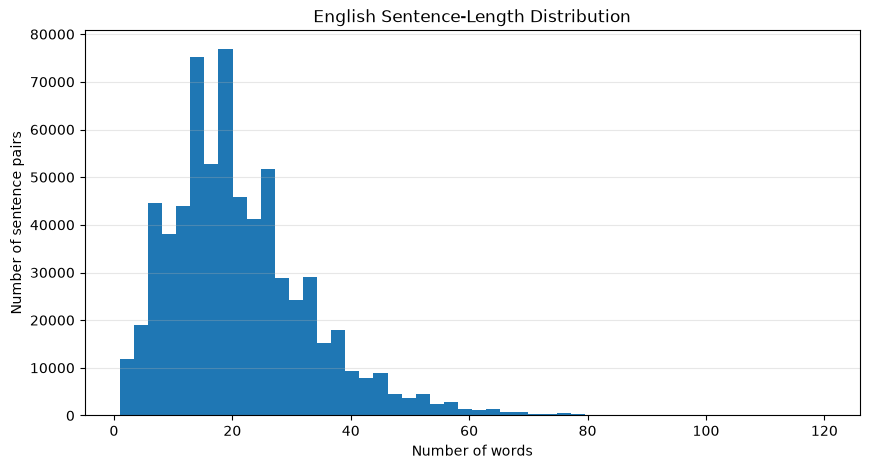

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_audit["eng_word_count"],
    bins=50
)

plt.title("English Sentence-Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Amharic sentence-length histogram

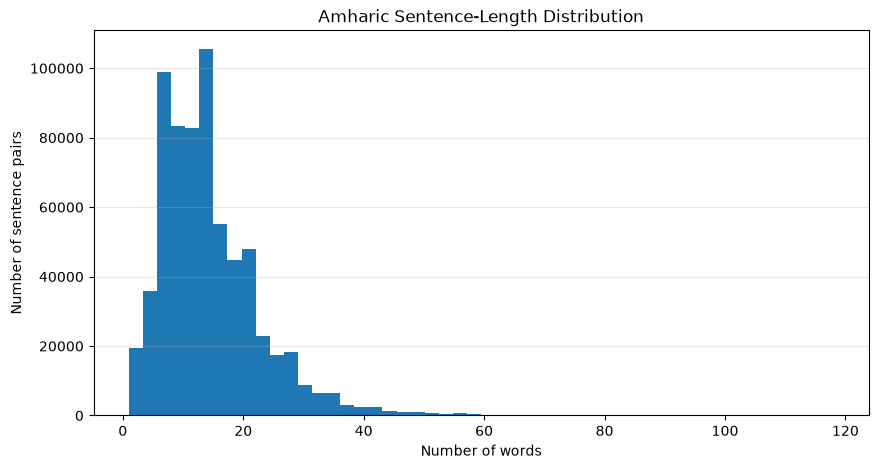

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_audit["amh_word_count"],
    bins=50
)

plt.title("Amharic Sentence-Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Compare both distributions

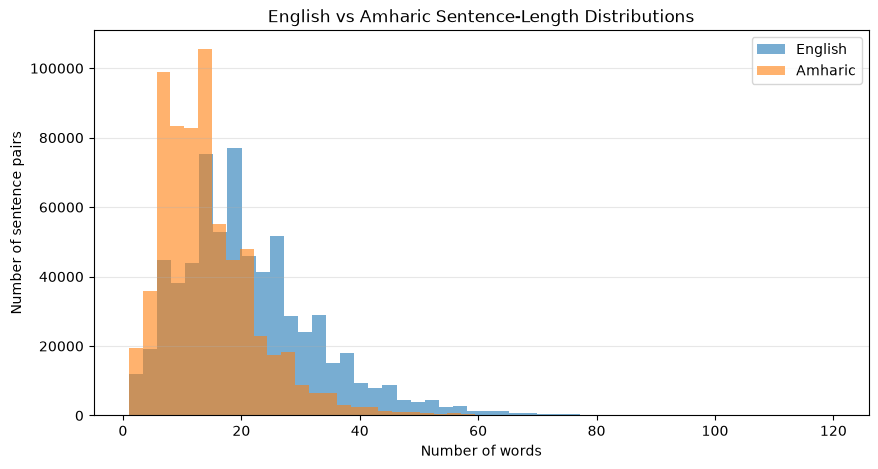

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_audit["eng_word_count"],
    bins=50,
    alpha=0.6,
    label="English"
)

plt.hist(
    df_audit["amh_word_count"],
    bins=50,
    alpha=0.6,
    label="Amharic"
)

plt.title("English vs Amharic Sentence-Length Distributions")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Length-Ratio Analysis

The length ratio is calculated as:

\[
\text{Length Ratio} =
\frac{\text{English word count}}
{\text{Amharic word count}}
\]

A very high or very low ratio may indicate:

- Poor alignment
- Missing translation content
- Formatting problems
- Different translation styles
- Legitimate linguistic differences

Therefore, extreme ratios should be inspected rather than automatically deleted.

### Calculate length ratios

In [27]:
df_audit["length_ratio_en_am"] = (
    df_audit["eng_word_count"] /
    df_audit["amh_word_count"].replace(0, np.nan)
)

display(
    df_audit["length_ratio_en_am"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .to_frame("English/Amharic length ratio")
)

,English/Amharic length ratio
count,669145.000000
mean,1.545927
std,0.593915
min,0.181818
1%,0.666667
5%,0.888889
50%,1.411765
95%,2.705882
99%,3.777778
max,10.000000


### Categorize length ratios

In [28]:
def classify_length_ratio(ratio):
    if pd.isna(ratio):
        return "undefined"
    if ratio > 4:
        return "English much longer"
    if ratio < 0.25:
        return "Amharic much longer"
    return "balanced"

df_audit["length_ratio_category"] = (
    df_audit["length_ratio_en_am"]
    .apply(classify_length_ratio)
)

ratio_summary = (
    df_audit["length_ratio_category"]
    .value_counts()
    .to_frame("count")
)

ratio_summary["percentage"] = (
    ratio_summary["count"] / len(df_audit) * 100
).round(4)

display(ratio_summary)

,count,percentage
length_ratio_category,,
balanced,664959,99.3744
English much longer,3977,0.5943
Amharic much longer,209,0.0312


### Inspect extreme length ratios

In [29]:
extreme_ratio_mask = df_audit["length_ratio_category"].isin([
    "English much longer",
    "Amharic much longer",
])

extreme_ratio_pairs = (
    df_audit.loc[
        extreme_ratio_mask,
        [
            "eng",
            "amh",
            "eng_word_count",
            "amh_word_count",
            "length_ratio_en_am",
            "length_ratio_category",
        ],
    ]
    .sort_values("length_ratio_en_am")
)

print(f"Extreme-ratio pairs: {len(extreme_ratio_pairs):,}")

display(extreme_ratio_pairs.head(20))
display(extreme_ratio_pairs.tail(20))

Extreme-ratio pairs: 4,186


,eng,amh,eng_word_count,amh_word_count,length_ratio_en_am,length_ratio_category
567195,Definitely !,"ብዙ ቋንቋዎችን የሚናገረውና ቀደም ሲል የተጠቀሰው ቢል "" እንዴታ ! """,2,11,0.181818,Amharic much longer
472823,Decagram,መምረጫዎች ( _ D ),1,5,0.200000,Amharic much longer
463000,Ribosomes,መካነ ፕሮቲን ( Ribosomes ),1,5,0.200000,Amharic much longer
466401,Images,ምስል ( _ I ),1,5,0.200000,Amharic much longer
103353,_ Fonts,የፊደል ቅርጽ ፦ ( _ F ) dialogs @-@ action,2,10,0.200000,Amharic much longer
632888,Help,መረጃ ( _ H ),1,5,0.200000,Amharic much longer
83838,18 : 13 .,""" እውነታውን ከመስማቱ በፊት መልስ የሚሰጥ ሰው ፣ ሞኝነት ይሆንበታል ፤ ውርደትም ይከናነባል ። "" - ምሳሌ 18 : 13",4,20,0.200000,Amharic much longer
108948,Cerebellum,አንጎለ ገቢር ( Cerebellum ),1,5,0.200000,Amharic much longer
117350,20 : 17 .,20 : 17 ፦ ' የይሖዋን ማዳን እንድናይ ' የአምላክን መንግሥት በንቃት በመደገፍ ' ቦታ ቦታችንን መያዝ ' ይኖርብናል ።,4,20,0.200000,Amharic much longer
117426,Neuron,ህዋሰ ነርቭ ( Neuron ),1,5,0.200000,Amharic much longer


,eng,amh,eng_word_count,amh_word_count,length_ratio_en_am,length_ratio_category
518989,"Truly "" in the Lord """,በጌታ,6,1,6.000000,English much longer
572467,""" If you feel the urge to cough or sneeze while with the gorillas , please turn away from the animals and try to cover your nose and mouth , "" says one of the guides .",በጭጋጋማ መኖሪያቸው እንግዶች መሆናችንን አትዘንጉ !,37,6,6.166667,English much longer
70214,"The Bible states : "" The whole world is lying in the power of the wicked one . """,የዚህ ዓለም ገዥ,19,3,6.333333,English much longer
662525,"Perhaps nothing grabs our attention more quickly than the words , "" Have you heard the latest ? """,ሰማህ እንዴ ?,19,3,6.333333,English much longer
459083,"These promoted tickets to live music , and included film reviews and , of course , product information .",መዋሸት አንጎልን ያደክማል,19,3,6.333333,English much longer
284640,""" The Son of man "" Jesus used this expression more than any other to refer to himself .",የሰው ልጅ ።,19,3,6.333333,English much longer
482352,"Most were Christian . "" "" If You Remain in My Word """,በትምህርቴ ብትጸኑ,13,2,6.500000,English much longer
628982,"Of China 's population of 1.2 billion , more than 300 million men and 20 million women are smokers .",ስብሰባ ላይ ናቸው,20,3,6.666667,English much longer
60263,I am not going to leave you,አልተውህም,7,1,7.000000,English much longer
237267,"Christ Jesus has been appointed by God to "" bring to nothing the one having the means to cause death , that is , the Devil . """,የዚህ ዓለም ገዥ ።,28,4,7.000000,English much longer


## 9. URL Analysis

URLs may introduce noise into a general translation corpus.

This section identifies pairs containing common URL patterns.

### Detect URLs

In [30]:
URL_RE = re.compile(
    r"(?:https?://|www\.)\S+",
    flags=re.IGNORECASE,
)

url_in_english = df_audit["eng"].fillna("").astype(str).str.contains(
    URL_RE,
    na=False,
)

url_in_amharic = df_audit["amh"].fillna("").astype(str).str.contains(
    URL_RE,
    na=False,
)

url_mask = url_in_english | url_in_amharic

url_report = pd.DataFrame({
    "count": [
        url_in_english.sum(),
        url_in_amharic.sum(),
        url_mask.sum(),
    ],
    "percentage": [
        url_in_english.mean() * 100,
        url_in_amharic.mean() * 100,
        url_mask.mean() * 100,
    ],
}, index=[
    "URL in English",
    "URL in Amharic",
    "URL in either sentence",
])

url_report["percentage"] = url_report["percentage"].round(4)

display(url_report)

,count,percentage
URL in English,180,0.0269
URL in Amharic,168,0.0251
URL in either sentence,202,0.0302


### Inspect URL-containing pairs

In [31]:
url_pairs = df.loc[url_mask, ["eng", "amh"]]

print(f"URL-containing pairs: {len(url_pairs):,}")

display(url_pairs.head(20))

URL-containing pairs: 202


,eng,amh
828,"To learn more about Jesus ' sacrifice and how you can benefit from it , watch the short video Remember Jesus ' Death at www.jw.org .",ስለ ኢየሱስ መሥዋዕትና የእሱ ሞት የሚጠቅምህ እንዴት እንደሆነ ይበልጥ ለማወቅ www.jw.org / am ላይ የሚገኘውን የኢየሱስ ሞት መታሰቢያ የሚለውን አጭር ቪዲዮ ተመልከት ።
2610,"Visit www.jw.org to sample written , audio , and video publications in your own language and in hundreds of other languages .",የመጀመሪያው ጽሑፍ የሚዘጋጀው በእንግሊዝኛ ነው ።
2978,published by Jehovah 's Witnesses . Also available at www.jw.org .,ይህ መጽሐፍ www.jw.org / am ላይም ይገኛል ።
3286,Also available at www.jw.org .,ጽሑፉ www.jw.org / am ላይም ይገኛል ።
5986,is published in Kirghiz and is available online at www.jw.org,የተባለው መጽሐፍ በኪርጊዝ ቋንቋ ታትሟል ፤ መጽሐፉ www.jw.org ላይም ይገኛል
8260,"If you would like to know more about this subject , you are invited to write to the publishers of this magazine , who will be glad to furnish further information , or visit our Web site at www.wat...",አሊያም www.watchtower.org የተባለውን ድረ ገጻችንን እንድትጎበኝ እናበረታታሃለን ።
8261,Or you may write to the appropriate address listed on page 4 or visit our Web site www.watchtower.org .,አሊያም ደግሞ በዚህ መጽሔት ገጽ 4 ላይ ካሉት አድራሻዎች ለአንተ አመቺ ወደሆነው መጻፍ ወይም www.watchtower.org የሚለውን ድረ ገጻችንን መጎብኘት ትችላለህ ።
12773,"For more information about God 's purpose to resurrect the dead , see chapter 7 of the book What Does the Bible Really Teach ?",የተባለውን መጽሐፍ ምዕራፍ 7 ተመልከት ፤ መጽሐፉ www.jw.org / am ላይም ይገኛል ።
14090,Source : www.kidshealth.org,ምንጭ ፦ www.kidshealth.org
16586,DNA : Photo : www.comstock.com,ዲ ኤን ኤ : - ፎቶ : - www.comstock.com


## 10. HTML and Markup Analysis

The raw corpus may contain HTML-like tags or markup symbols.

These examples will be inspected before applying the cleaning pipeline.

### Detect HTML-like tags

In [32]:
HTML_TAG_RE = re.compile(r"<[^>]+>")

html_in_english = df_audit["eng"].fillna("").astype(str).str.contains(
    HTML_TAG_RE,
    na=False,
)

html_in_amharic = df_audit["amh"].fillna("").astype(str).str.contains(
    HTML_TAG_RE,
    na=False,
)

html_mask = html_in_english | html_in_amharic

markup_report = pd.DataFrame({
    "count": [
        html_in_english.sum(),
        html_in_amharic.sum(),
        html_mask.sum(),
    ],
    "percentage": [
        html_in_english.mean() * 100,
        html_in_amharic.mean() * 100,
        html_mask.mean() * 100,
    ],
}, index=[
    "Markup in English",
    "Markup in Amharic",
    "Markup in either sentence",
])

markup_report["percentage"] = markup_report["percentage"].round(4)

display(markup_report)

,count,percentage
Markup in English,114,0.0170
Markup in Amharic,9,0.0013
Markup in either sentence,115,0.0172


### Inspect markup examples

In [33]:
markup_pairs = df.loc[html_mask, ["eng", "amh"]]

print(f"Pairs containing HTML-like markup: {len(markup_pairs):,}")

display(markup_pairs.head(20))

Pairs containing HTML-like markup: 115


,eng,amh
18374,"< < For the Chief Musician . For a stringed instrument . By David . > > Hear my cry , God . Listen to my prayer .",አምላክ ሆይ ፥ ልመናዬን ስማ ፥ ጸሎቴንም አድምጥ ።
21354,"< < For the Chief Musician . To the tune of "" Do Not Destroy . "" A poem by David . > > Do you indeed speak righteousness , silent ones ? Do you judge blamelessly , you sons of men ?",በእውነት ጽድቅን ብትናገሩስ ፥ የሰው ልጆች ሆይ ፥ በቅን ትፈርዳላችሁ ፤
22331,< < A Psalm by David . > > Yahweh is my shepherd : I shall lack nothing .,እግዚአብሔር እረኛዬ ነው ፥ የሚያሳጣኝም የለም ።
29710,"< < A Psalm by David . > > Ascribe to Yahweh , you sons of the mighty , ascribe to Yahweh glory and strength .",የአምላክ ልጆች ሆይ ፥ ለእግዚአብሔር አምጡ ። ክብርንና ምስጋናን ለእግዚአብሔር አምጡ ።
30751,"< < A Psalm . > > Sing to Yahweh a new song , for he has done marvelous things ! His right hand , and his holy arm , have worked salvation for him .",ለእግዚአብሔር አዲስ ምስጋናን አመስግኑ ፥ እግዚአብሔር ተኣምራትን አድርጎአልና ፤ ቀኙ የተቀደሰም ክንዱ ለእርሱ ማዳን አደረገ ።
42028,"< < A Psalm by David . > > Yahweh , who shall dwell in your sanctuary ? Who shall live on your holy hill ?",አቤቱ ፥ በድንኳንህ ውስጥ ማን ያድራል ? በተቀደሰውም ተራራህ ማን ይኖራል ?
48668,"< < A contemplation by Asaph . > > God , why have you rejected us forever ? Why does your anger smolder against the sheep of your pasture ?",አቤቱ ፥ ስለ ምን ለዘወትር ጣልኸኝ ? በማሰማርያህ በጎች ላይስ ቍጣህን ስለ ምን ተቈጣህ ?
61856,"< < For the Chief Musician . A Psalm by the sons of Korah . > > Oh clap your hands , all you nations . Shout to God with the voice of triumph !",አሕዛብ ሁላችሁ ፥ እጆቻችሁን አጨብጭቡ ፥ በደስታ ቃልም ለእግዚአብሔር እልል በሉ ።
61922,"< < For the Chief Musician . To the tune of "" Lilies . "" By David . > > Save me , God , for the waters have come up to my neck !",አቤቱ ፥ ውኃ እስከ ነፍሴ ደርሶብኛልና አድነኝ ።
73757,"--description < description \ _ BAR _ file > , -D < description \ _ BAR _ file > Provide a descriptive name for the command to be used in the default message , making it nicer . You can also provi...","--መግለጫ < description \ _ BAR _ file > , -መ < description \ _ BAR _ file > ማቅረብ መግለጫ ስም ለትእዛዙ እንዲጠቀምበት በነበረው መልእክት , ጥሩ እንዲያደርገው . እንዲሁም ማቅረብ ይችላሉ ሁሉንም መንገድ ለዴስክቶፕ ፋይል . ቁልፍ ስምን ይጠቀማል በዚህ ሁኔታ"


## 11. Ethiopic-Script Validation

Amharic text normally uses the Ethiopic Unicode block:

- Ethiopic range: `U+1200`–`U+137F`

This check is only a basic integrity check. It does not determine whether a sentence is grammatically correct Amharic.

### Ethiopic-script detection

In [34]:
ETHIOPIC_RE = re.compile(r"[\u1200-\u137F]")

amharic_has_ethiopic = df_audit["amh"].fillna("").astype(str).apply(
    lambda text: bool(ETHIOPIC_RE.search(text))
)

ethiopic_report = pd.DataFrame({
    "count": [
        amharic_has_ethiopic.sum(),
        (~amharic_has_ethiopic).sum(),
    ],
    "percentage": [
        amharic_has_ethiopic.mean() * 100,
        (~amharic_has_ethiopic).mean() * 100,
    ],
}, index=[
    "Amharic target contains Ethiopic characters",
    "Amharic target has no Ethiopic characters",
])

ethiopic_report["percentage"] = ethiopic_report["percentage"].round(4)

display(ethiopic_report)

,count,percentage
Amharic target contains Ethiopic characters,666393,99.5887
Amharic target has no Ethiopic characters,2752,0.4113


### Inspect targets without Ethiopic characters

In [35]:
without_ethiopic = df.loc[
    ~amharic_has_ethiopic,
    ["eng", "amh"]
]

print(f"Pairs without Ethiopic characters: {len(without_ethiopic):,}")

display(without_ethiopic.head(20))

Pairs without Ethiopic characters: 2,752


,eng,amh
208,- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -,- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
212,"1 : 1 , 3 .","1 : 1 , 3"
217,11 : 31 .,11 : 31
223,136 : 11 - 15 .,136 : 11 - 15
225,145 : 16 .,145 : 16
226,"15 , 16 . ( a ) What quality should distinguish Christian families ?","15 , 16 ."
229,"16 : 17 , 18 .","16 : 17 , 18"
230,"17 , 18 . ( a ) What fear - inspiring day of Jehovah came upon Jerusalem ?","17 , 18 ."
234,22 : 2 - 4 .,22 : 2 - 4
244,4 : 25 .,4 : 25


## 12. Extreme-Length Sentence Inspection

### English sentences longer than 100 words

In [36]:
english_over_100 = df_audit["eng_word_count"] > 100

print(f"English sentences longer than 100 words: {english_over_100.sum():,}")

display(
    df_audit.loc[
        english_over_100,
        ["eng", "amh", "eng_word_count", "amh_word_count"]
    ].head(20)
)

English sentences longer than 100 words: 263


,eng,amh,eng_word_count,amh_word_count
179,"If you do not help him , then Allah certainly helped him when the faithless expelled him , as one of two [ refugees ] , when the two of them were in the cave , he said to his companion , ' Do not ...",( ነቢዩን ) ባትረዱት እነዚያ የካዱት ሕዝቦች የሁለት ( ሰዎች ) ሁለተኛ ኾኖ ( ከመካ ) ባወጡት ጊዜ አላህ በእርግጥ ረድቶታል ፡ ፡ ሁለቱም በዋሻው ሳሉ ለጓደኛው አትዘን አላህ ከእኛ ጋር ነውና ባለ ጊዜ አላህም መረጋጋትን በእርሱ ላይ አወረደ ፡ ፡ ባላያችኋቸውም ሰራዊት አበረታው ፡ ፡ የእነዚያንም የካዱ...,104,67
190,"Ramadan is the month in which the Qur ' an was revealed as guidance to man and clear proof of the guidance , and criterion ( of falsehood and truth ) . So when you see the new moon you should fast...",( እንድትጾሙ የተጻፈባችሁ ) ያ በርሱ ውስጥ ለሰዎች መሪ ከቅን መንገድና ( እውነትን ከውሸት ) ከሚለዩም ገላጮች ( አንቀጾች ) ሲኾን ቁርኣን የተወረደበት የረመዳን ወር ነው ፡ ፡ ከእናንተም ወሩን ያገኘ ሰው ይጹመው ፡ ፡ በሽተኛ ወይም በጉዞ ላይ የኾነም ሰው ከሌሎች ቀኖች ቁጥሮችን ( በልኩ ) መጾም አለ...,104,80
3948,"Proverbs 2 : 1 - 5 says : "" My son , if you will receive my sayings and treasure up my own commandments with yourself , so as to pay attention to wisdom with your ear , that you may incline your h...","ምሳሌ 2 : 1 - 5 እንዲህ ይላል : - "" ልጄ ሆይ ፣ ቃሌን ብትቀበል ፣ ትእዛዜንም በአንተ ዘንድ ሸሽገህ ብትይዛት ፣ ጆሮህ ጥበብን እንዲያደምጥ ታደርጋለህ ፣ ልብህንም ወደ ማስተዋል ታዘነብላለህ ።",110,33
7093,"- those who follow the Apostle , the untaught prophet , whose mention they find written with them in the Torah and the Evangel , who bids them to do what is right and forbids them from what is wro...",ለእነዚያ ያንን እነሱ ዘንድ በተውራትና በኢንጂል ተጽፎ የሚያገኙትን የማይጽፍና የማያነብ ነቢይ የኾነውን መልክተኛ የሚከተሉ ለኾኑት ( በእርግጥ እጽፍለታለሁ ) ፡ ፡ በበጎ ሥራ ያዛቸዋል ፡ ፡ ከክፉም ነገር ይከለክላቸዋል ፡ ፡ መልካም ነገሮችንም ለነርሱ ይፈቅድላቸዋል ፡ ፡ መጥፎ ነገሮችንም በእነርሱ ላይ እር...,101,77
12590,"He had turned water into wine , had healed a dying boy , had cured Peter 's sick mother - in - law , had made a leprous man clean , had enabled a paralyzed man to walk , had restored the health of...",ውኃ ወደ ወይን ለውጧል ፣ በጠና ታሞ የነበረ አንድ ብላቴና ፈውሷል ፣ ታምማ የነበረችውን የጴጥሮስን አማት ፈውሷል ፣ የሥጋ ደዌ የነበረበትን ሰው ከደዌ አንጽቶታል ፣ ሽባ የነበረው ሰውዬ በእግሮቹ እንዲራመድ አድርጓል ፣ ለ38 ዓመታት ታምሞ ሲሰቃይ የነበረው ሰው ጤንነቱ እንዲመለስለት አድርጓል ፣ እጁ የሰለለ...,102,72
14032,"And Moses chose seventy of his people for Our place of meeting : when they were seized with violent quaking , he prayed : "" O my Lord ! if it had been Thy will Thou couldst have destroyed , long b...","ሙሳም ከሕዝቦቹ ውስጥ ለቀጠሮዋችን ሰባን ሰዎች መረጠ ፡ ፡ ብርቱ የምድር እንቅጥቃጤ በያዘቻቸውም ጊዜ ሙሳ አለ "" ጌታዬ ሆይ ! በሻህ ኖሮ ከአሁን በፊት በአጠፋሃቸው ነበር ፡ ፡ እኔንም ( ባጠፋኸኝ ነበር ) ፡ ፡ ከእኛ ቂሎቹ በሠሩት ነገር ታጠፋናለህን እርሷ ( ፈተናይቱ ) ያንተ ፈተና እንጂ ሌላ አይደለች...",115,79
16239,"For , if a man with gold rings on his fingers and in splendid clothing enters into a gathering of you , but a poor man in filthy clothing also enters , yet you look with favor upon the one wearing...",የወርቅ ቀለበት ያደረገና የጌጥ ልብስ የለበሰ ሰው ወደ ጉባኤአችሁ ቢገባ ፣ እድፍ ልብስም የለበሰ ድሀ ሰው ደግሞ ቢገባ ፣ የጌጥ ልብስም የለበሰውን ተመልክታችሁ : - አንተስ በዚህ በመልካም ስፍራ ተቀመጥ ብትሉት ፣ ድሀውንም : - አንተስ ወደዚያ ቁም ወይም ከእግሬ መረገጫ በታች ተቀመጥ ብትሉት ፣ ራሳችሁን ...,114,64
16950,"The month of Ramadan in which was sent down the Qur ' an - the guidance for mankind , the direction and the clear criteria ( to judge between right and wrong ) ; so whoever among you witnesses thi...",( እንድትጾሙ የተጻፈባችሁ ) ያ በርሱ ውስጥ ለሰዎች መሪ ከቅን መንገድና ( እውነትን ከውሸት ) ከሚለዩም ገላጮች ( አንቀጾች ) ሲኾን ቁርኣን የተወረደበት የረመዳን ወር ነው ፡ ፡ ከእናንተም ወሩን ያገኘ ሰው ይጹመው ፡ ፡ በሽተኛ ወይም በጉዞ ላይ የኾነም ሰው ከሌሎች ቀኖች ቁጥሮችን ( በልኩ ) መጾም አለ...,112,80
17177,"And if you divorce them before you have touched ( had a sexual relation with ) them , and you have appointed unto them the Mahr ( bridal money given by the husbands to his wife at the time of marr...",ለእነርሱም መወሰንን በእርግጥ የወሰናችሁላቸው ስትኾኑ ሳትነኳቸው በፊት ብተፈቷቸው ካልማሩዋችሁ ወይም ያ የጋብቻው ውል በእጁ የኾነው ( ባልየው ) ካልማረ በስተቀር የወሰናችሁት ግማሹ አላቸው ፡ ፡ ምሕረትም ማድረጋችሁ ወደ አላህ ፍራቻ በጣም የቀረበ ነው ፡ ፡ በመካከላችሁም ችሮታን አትርሱ ፤ አላህ የምትሠሩት...,116,46
28757,"Brown Chapel A.M.E. Church is a church in Selma , Alabama , United States . This church was a starting point for the Selma to Montgomery marches in 1965 and , as the meeting place and offices of t...","አዲስ ይሄዱ ሀ . ኤም ሠ . ቤተ ክርስቲያን ያለ ቤተ ክርስቲያን ውስጥ Selma , በይፋ , ስቴትስ . ይህች ቤተ @-@ ክርስቲያን ነ

### Amharic sentences longer than 100 words

In [37]:
amharic_over_100 = df_audit["amh_word_count"] > 100

print(f"Amharic sentences longer than 100 words: {amharic_over_100.sum():,}")

display(
    df_audit.loc[
        amharic_over_100,
        ["eng", "amh", "eng_word_count", "amh_word_count"]
    ].head(20)
)

Amharic sentences longer than 100 words: 83


,eng,amh,eng_word_count,amh_word_count
1244,"This day have those who disbelieve despaired of your religion , so fear them not , and fear Me . This day have I perfected for you your religion and completed My favor on you and chosen for you Is...",በክት ፣ ፈሳሽ ደምም ፣ የእሪያ ( አሣማ ) ሥጋም ፣ በርሱ ከአላህ ( ስም ) ሌላ የተነሳበትም ፣ የታነቀችም ፣ ተደብድባ የተገደለችም ፣ ተንከባላ የሞተችም ፣ በቀንድ ተውግታ የሞተችም ፣ ከርሷ አውሬ የበላላትም ( ከእነዚህ በሕይወት ደርሳችሁ ) ያረዳችሁት ብቻ ሲቀር ለጣዖታትም የታረደው በአዝላምም ዕድልን...,65,117
4883,"God instructs you regarding your children : The male receives the equivalent of the share of two females . If they are daughters , more than two , they get two @-@ thirds of what he leaves .",አላህ በልጆቻችሁ ( ውርስ በሚከተለው ) ያዛችኋል ፡ ፡ ለወንዱ የሁለት ሴቶች ድርሻ ብጤ አለው ፡ ፡ ( ሁለት ወይም ) ከሁለት በላይም የኾኑ ሴቶች ብቻ ቢኾኑ ለእነሱ ( ሟቹ ) ከተወው ረጀት ( ድርሻ ) ከሦስት ሁለት እጁ አላቸው ፡ ፡ አንዲትም ብትኾን ለርሷ ግማሹ አላት ፡ ፡ ለአባትና ለእናቱም ለእርሱ ...,38,118
5314,But none should be burdened with more than one can bear : neither the mother should be pressed unjustly ( to accept unfair terms ) just because she is the mother nor should the father be burdened ...,እናቶችም ልጆቻቸውን ሙሉ የኾኑን ሁለት ዓመታት ያጥቡ ፡ ፡ ( ይህም ) ማጥባትን መሙላት ለሻ ሰው ነው ፡ ፡ ለእርሱም በተወለደለት ( አባት ) ላይ ምግባቸውና ልብሳቸው በችሎታው ልክ አለበት ፡ ፡ ነፍስ ችሎታዋን እንጂ አትገደድም ፡ ፡ ወላጂት ( እናት ) በልጅዋ ምክንያት ለርሱ የተወለደለትም ( አባት ) ...,65,111
25867,"Say , "" Fighting is a heinous offence in this month , but in the sight of Allah it is far worse to hinder people from the Way of Allah and to deny Him and to prevent His worshippers from visiting ...","ከተከበረው ወር ( ከረጀብ ) በርሱ ውስጥ ከመጋደል ይጠይቁሃል ፡ ፡ በላቸው "" በርሱ ውስጥ መጋደል ታላቅ ( ኀጢአት ) ነው ፡ ፡ ግን ከአላህ መንገድ ( ሰዎችን ) መከላከል ፣ በርሱም መካድ ፣ ከተከበረውም መስጊድ ( ማገድ ) ባለቤቶቹንም ከርሱ ማውጣት አላህ ዘንድ ይበልጥ ታላቅ ( ወንጀል ) ነው ፡ ፡ ...",92,108
35721,"If they both decide on weaning , by mutual consent , and after due consultation , there is no blame on them . If ye decide on a foster @-@ mother for your offspring , there is no blame on you , pr...",እናቶችም ልጆቻቸውን ሙሉ የኾኑን ሁለት ዓመታት ያጥቡ ፡ ፡ ( ይህም ) ማጥባትን መሙላት ለሻ ሰው ነው ፡ ፡ ለእርሱም በተወለደለት ( አባት ) ላይ ምግባቸውና ልብሳቸው በችሎታው ልክ አለበት ፡ ፡ ነፍስ ችሎታዋን እንጂ አትገደድም ፡ ፡ ወላጂት ( እናት ) በልጅዋ ምክንያት ለርሱ የተወለደለትም ( አባት ) ...,57,111
45938,"Say , "" To fight [ in a sacred month ] is a grave matter ; but barring people from the path of God , to deny Him , and expelling people from the Sacred Mosque are far graver in His sight ; and per...","ከተከበረው ወር ( ከረጀብ ) በርሱ ውስጥ ከመጋደል ይጠይቁሃል ፡ ፡ በላቸው "" በርሱ ውስጥ መጋደል ታላቅ ( ኀጢአት ) ነው ፡ ፡ ግን ከአላህ መንገድ ( ሰዎችን ) መከላከል ፣ በርሱም መካድ ፣ ከተከበረውም መስጊድ ( ማገድ ) ባለቤቶቹንም ከርሱ ማውጣት አላህ ዘንድ ይበልጥ ታላቅ ( ወንጀል ) ነው ፡ ፡ ...",69,108
61841,"Parents of the deceased will each inherit one @-@ sixth of the legacy , if the deceased has a surviving child , however , if no children survive the deceased , and the heirs are the parents , the ...",አላህ በልጆቻችሁ ( ውርስ በሚከተለው ) ያዛችኋል ፡ ፡ ለወንዱ የሁለት ሴቶች ድርሻ ብጤ አለው ፡ ፡ ( ሁለት ወይም ) ከሁለት በላይም የኾኑ ሴቶች ብቻ ቢኾኑ ለእነሱ ( ሟቹ ) ከተወው ረጀት ( ድርሻ ) ከሦስት ሁለት እጁ አላቸው ፡ ፡ አንዲትም ብትኾን ለርሷ ግማሹ አላት ፡ ፡ ለአባትና ለእናቱም ለእርሱ ...,69,118
68416,"If ( the heirs of the deceased are ) more than two daughters , they shall have two @-@ thirds of the inheritance ; and if there is only one daughter , then she shall have half the inheritance . If...",አላህ በልጆቻችሁ ( ውርስ በሚከተለው ) ያዛችኋል ፡ ፡ ለወንዱ የሁለት ሴቶች ድርሻ ብጤ አለው ፡ ፡ ( ሁለት ወይም ) ከሁለት በላይም የኾኑ ሴቶች ብቻ ቢኾኑ ለእነሱ ( ሟቹ ) ከተወው ረጀት ( ድርሻ ) ከሦስት ሁለት እጁ አላቸው ፡ ፡ አንዲትም ብትኾን ለርሷ ግማሹ አላት ፡ ፡ ለአባትና ለእናቱም ለእርሱ ...,102,118
68886,"But if you are ill or on a journey or any of you comes from answering the call of nature , or you have been in contact with women ( i.e. sexual intercourse ) and you find no water , then perform T...","እናንተ ያመናችሁ ሆይ ! ወደ ሶላት በቆማችሁ ( ለመቆም ባሰባችሁ ) ጊዜ ፊቶቻችሁን ፣ እጆቻችሁንም እስከ ክርኖች እጠቡ ፡ ፡ ራሶቻችሁንም ( በውሃ ) አብሱ ፡ ፡ እግሮቻችሁንም እስከ ቁርጭምጭሚቶች ( እጠቡ ) ፡ ፡ ( ሴት ጋር በመገናኘት ወይም በሌላ ምክንያት "" ጀናባ "" ) ብትኾኑ ( ገላችሁን ) ታጠቡ...",84,101
75827,"Dissension is greater than killing ' They will not cease to fight against you until they force you to renounce your religion , if they are able . But whosoever of you recants from his religion and...","ከተከበረው ወር ( ከረጀብ )

### Very short sentence pairs

In [38]:
very_short_pairs = (
    (df_audit["eng_word_count"] < 2) |
    (df_audit["amh_word_count"] < 2)
)

print(f"Pairs with at least one very short sentence: {very_short_pairs.sum():,}")

display(
    df_audit.loc[
        very_short_pairs,
        ["eng", "amh", "eng_word_count", "amh_word_count"]
    ].head(20)
)

Pairs with at least one very short sentence: 3,468


,eng,amh,eng_word_count,amh_word_count
10,It Is Enough !,በቅቶኛል,4,1
318,"""","ሆነብኝ ። """,1,3
449,LYCAONIA,ሊቃኦንያ,1,1
692,ANIMALS AND PLANTS,ማውጫ,3,1
806,Seraphs,ሱራፌል,1,1
877,Cyrene,ቀሬና,1,1
1427,Bangalore,ባንጋሎር,1,1
1469,Ventotene,ቬንቶቴኔ,1,1
1470,No sources selected .,ተመርጠዋል,4,1
1486,Template Parameters,ቲምፕሌቶች,2,1


## 13. Raw Dataset Audit Summary

### Build audit summary

In [39]:
audit_summary = {
    "Total rows": len(df),
    "Total columns": len(df.columns),
    "Missing English values": int(df["eng"].isna().sum()),
    "Missing Amharic values": int(df["amh"].isna().sum()),
    "Empty English values": int(eng_as_text.str.strip().eq("").sum()),
    "Empty Amharic values": int(amh_as_text.str.strip().eq("").sum()),
    "Exact duplicate rows": int(df.duplicated(["eng", "amh"]).sum()),
    "Repeated English source rows": int(repeated_english_sources.sum()),
    "Repeated Amharic target rows": int(repeated_amharic_targets.sum()),
    "URL-containing pairs": int(url_mask.sum()),
    "Markup-containing pairs": int(html_mask.sum()),
    "Targets without Ethiopic characters": int((~amharic_has_ethiopic).sum()),
    "English sentences over 100 words": int(english_over_100.sum()),
    "Amharic sentences over 100 words": int(amharic_over_100.sum()),
    "Extreme length-ratio pairs": int(extreme_ratio_mask.sum()),
}

audit_summary_df = pd.DataFrame(
    list(audit_summary.items()),
    columns=["Audit item", "Value"]
)

display(audit_summary_df)

,Audit item,Value
0,Total rows,669145
1,Total columns,2
2,Missing English values,0
3,Missing Amharic values,0
4,Empty English values,0
5,Empty Amharic values,0
6,Exact duplicate rows,51
7,Repeated English source rows,14467
8,Repeated Amharic target rows,130742
9,URL-containing pairs,202


## 14. Audit Conclusions

Based on this audit:

1. The raw dataset structure and required columns were verified.
2. Missing and empty values were examined.
3. Exact duplicate translation pairs were identified.
4. Repeated English and Amharic sentences were measured separately.
5. Sentence-length distributions and extreme length ratios were analyzed.
6. URL-containing and markup-containing pairs were inspected.
7. Amharic targets were checked for Ethiopic characters.
8. Potentially problematic pairs were inspected before cleaning.

The raw dataset will now be processed using the project's centralized cleaning pipeline:

```text
src/nmt/data/clean.py